# 11 — Truy tận gốc: bản thân THỜI LƯỢNG ĐI có dự đoán được không?

`09_yeuto_gia_co_ban.ipynb` phát hiện: khi cố định quãng đường, **thời lượng đi (tắc đường)** là
yếu tố duy nhất ảnh hưởng rõ đến giá cơ bản (chênh ~32% giữa nhóm nhanh nhất/chậm nhất).

Câu hỏi tiếp theo: **bản thân thời lượng đó có dự đoán được từ giờ/thứ/thời tiết không**, hay nó
cũng là một dạng "nhiễu" — tắc đường xảy ra ngẫu nhiên chứ không theo quy luật giờ cao điểm?

Nếu thời lượng **không dự đoán được**, thì phần "giải thích được" của giá cơ bản (~19%) chỉ có giá
trị khi đã **quan sát trực tiếp** thời lượng của đúng chuyến đó (giống ETA thật khi khách bấm đặt xe)
— chứ không thể dự đoán trước bằng ngữ cảnh (giờ, thời tiết) cho 1 chuyến chưa xảy ra.

In [1]:
import sys; sys.path.insert(0, ".")
from _common import *
import numpy as np, pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
setup()
df = load(frac=0.3)
df["base_price"] = df[PRICE] / df[SURGE].clip(lower=0.1)

dv0 = df.service_name.iloc[0]
band = df[(df.pickup_location_name=="Crescent Mall") & (df.dropoff_location_name=="SC Vivo City") &
          (df.service_name==dv0) & (df.quote_distance.between(5.4, 5.6))].copy()
band["co_mua"] = ((band.weather_is_rain==1)|(band.weather_is_drizzle==1)|(band.weather_is_thunderstorm==1)).astype(int)
print(f"Band: {len(band):,} chuyen (cung tuyen+xe+quang duong)")
print(f"Thoi luong: {band.quote_duration.min()/60:.1f} - {band.quote_duration.max()/60:.1f} phut "
      f"(median {band.quote_duration.median()/60:.1f}p, CV={band.quote_duration.std()/band.quote_duration.mean()*100:.1f}%)")

Nap 2,069,167 dong (mau 30%) | gia median 114k VND | surge 81.7%
Band: 22,722 chuyen (cung tuyen+xe+quang duong)
Thoi luong: 4.3 - 85.4 phut (median 18.9p, CV=34.8%)


---
## 1. Giờ/thứ/thời tiết giải thích được bao nhiêu % biến thiên THỜI LƯỢNG?

In [2]:
rows = [
    {"Yeu to": "Gio trong ngay", "eta": eta(band.gio_vn, band.quote_duration)},
    {"Yeu to": "Thu trong tuan", "eta": eta(band.thu_vn, band.quote_duration)},
    {"Yeu to": "Loai thoi tiet", "eta": eta(band.weather_main, band.quote_duration)},
    {"Yeu to": "Co mua / khong", "eta": eta(band.co_mua, band.quote_duration)},
]
bang = pd.DataFrame(rows).sort_values("eta", ascending=False)
bang["eta"] = bang["eta"].round(3)
display(bang.reset_index(drop=True))

FEATS = ["gio_vn", "thu_vn", "weather_main"]
X = band[FEATS].copy(); X["weather_main"] = X["weather_main"].astype("category")
Xtr, Xte, ytr, yte = train_test_split(X, band.quote_duration.values, test_size=0.25, random_state=42)
m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
    categorical_features=["weather_main"], random_state=42).fit(Xtr, ytr)
r2 = r2_score(yte, m.predict(Xte))
print(f"\nR2(thoi luong ~ gio + thu + thoi tiet) = {r2:.4f} ({r2*100:.1f}%)")
print("-> Rat thap: gio/thu/thoi tiet GAN NHU KHONG du doan duoc thoi luong cua 1 chuyen cu the.")

,Yeu to,eta
0,Loai thoi tiet,0.151
1,Co mua / khong,0.151
2,Gio trong ngay,0.068
3,Thu trong tuan,0.017



R2(thoi luong ~ gio + thu + thoi tiet) = 0.0352 (3.5%)
-> Rat thap: gio/thu/thoi tiet GAN NHU KHONG du doan duoc thoi luong cua 1 chuyen cu the.


---
## 2. Vẽ trực tiếp: thời lượng theo giờ — có mẫu hình rõ không?

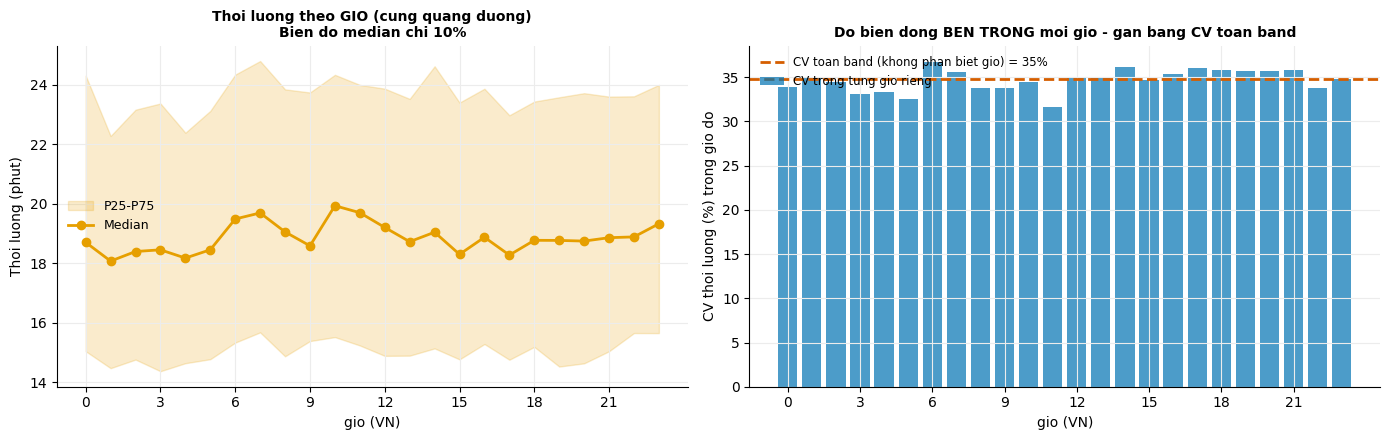

CV thoi luong TRONG cung 1 gio (trung binh)  = 34.7%
CV thoi luong TOAN band (khong phan biet gio) = 34.8%
-> 2 con so GAN NHU BANG NHAU -> biet gio khong giup thu hep du doan thoi luong bao nhieu.


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

g = band.groupby("gio_vn").quote_duration.agg(["median", lambda s: s.quantile(.25), lambda s: s.quantile(.75)])
g.columns = ["median", "P25", "P75"]
ax[0].fill_between(g.index, g.P25/60, g.P75/60, alpha=.2, color=ORANGE, label="P25-P75")
ax[0].plot(g.index, g["median"]/60, marker="o", lw=2, color=ORANGE, label="Median")
ax[0].set_xlabel("gio (VN)"); ax[0].set_ylabel("Thoi luong (phut)")
ax[0].set_xticks(range(0,24,3))
ax[0].set_title(f"Thoi luong theo GIO (cung quang duong)\nBien do median chi {(g['median'].max()/g['median'].min()-1)*100:.0f}%",
                fontweight="bold", fontsize=10)
ax[0].legend(frameon=False, fontsize=9)

# So sanh CV trong cung 1 gio vs toan bo
cv_theo_gio = band.groupby("gio_vn").quote_duration.apply(lambda s: s.std()/s.mean()*100)
cv_toan_bo = band.quote_duration.std()/band.quote_duration.mean()*100
ax[1].bar(cv_theo_gio.index, cv_theo_gio.values, color=BLUE, alpha=.7, label="CV trong tung gio rieng")
ax[1].axhline(cv_toan_bo, color=RED, ls="--", lw=2, label=f"CV toan band (khong phan biet gio) = {cv_toan_bo:.0f}%")
ax[1].set_xlabel("gio (VN)"); ax[1].set_ylabel("CV thoi luong (%) trong gio do")
ax[1].set_xticks(range(0,24,3))
ax[1].set_title("Do bien dong BEN TRONG moi gio - gan bang CV toan band", fontweight="bold", fontsize=10)
ax[1].legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

print(f"CV thoi luong TRONG cung 1 gio (trung binh)  = {cv_theo_gio.mean():.1f}%")
print(f"CV thoi luong TOAN band (khong phan biet gio) = {cv_toan_bo:.1f}%")
print("-> 2 con so GAN NHU BANG NHAU -> biet gio khong giup thu hep du doan thoi luong bao nhieu.")

---
## 3. Phần "giải thích giá" của thời lượng đến từ đâu — quy luật giờ hay khác biệt ngẫu nhiên
giữa các chuyến?

Tách thời lượng thành 2 phần: **trung bình theo giờ** (phần có quy luật) + **phần dư riêng từng
chuyến** (phần "may rủi" cụ thể của chuyến đó). So xem phần nào tương quan với giá cơ bản mạnh hơn.

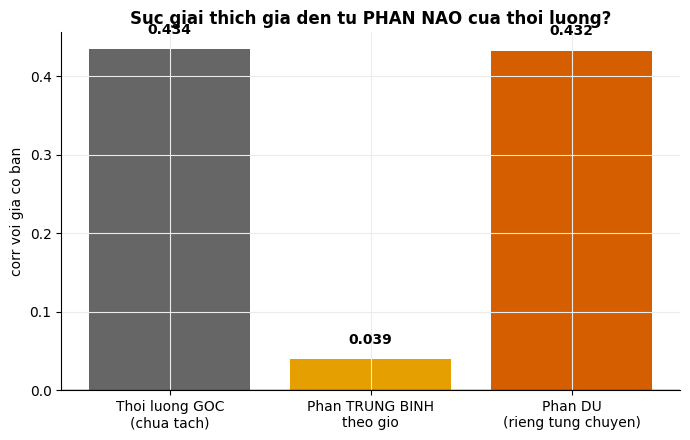

corr(thoi luong GOC, gia co ban)              = +0.434
corr(phan TRUNG BINH theo gio, gia co ban)     = +0.039
corr(phan DU rieng tung chuyen, gia co ban)    = +0.432

-> Phan DU (khac biet ngau nhien giua cac chuyen, KHONG lien quan gio) giai thich
   gan het suc manh cua thoi luong (0.432 so voi 0.434 ban dau).
   Phan lien quan den gio chi dong gop rat it (0.039).


In [4]:
band["duration_TB_theo_gio"] = band.groupby("gio_vn").quote_duration.transform("mean")
band["duration_du"] = band.quote_duration - band["duration_TB_theo_gio"]

corr_goc = band.quote_duration.corr(band.base_price)
corr_du = band.duration_du.corr(band.base_price)
corr_tb_gio = band.duration_TB_theo_gio.corr(band.base_price)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(["Thoi luong GOC\n(chua tach)", "Phan TRUNG BINH\ntheo gio", "Phan DU\n(rieng tung chuyen)"],
       [corr_goc, corr_tb_gio, corr_du], color=[MUT, ORANGE, RED])
ax.axhline(0, color="#222", lw=1)
ax.set_ylabel("corr voi gia co ban")
ax.set_title("Suc giai thich gia den tu PHAN NAO cua thoi luong?", fontweight="bold")
for i, v in enumerate([corr_goc, corr_tb_gio, corr_du]):
    ax.text(i, v+0.02, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"corr(thoi luong GOC, gia co ban)              = {corr_goc:+.3f}")
print(f"corr(phan TRUNG BINH theo gio, gia co ban)     = {corr_tb_gio:+.3f}")
print(f"corr(phan DU rieng tung chuyen, gia co ban)    = {corr_du:+.3f}")
print(f"\n-> Phan DU (khac biet ngau nhien giua cac chuyen, KHONG lien quan gio) giai thich")
print(f"   gan het suc manh cua thoi luong ({corr_du:.3f} so voi {corr_goc:.3f} ban dau).")
print(f"   Phan lien quan den gio chi dong gop rat it ({corr_tb_gio:.3f}).")

---
## Kết luận

### Bảng tóm tắt

| Câu hỏi | Trả lời |
|---|---|
| Giờ/thứ/thời tiết giải thích được bao nhiêu % thời lượng? | Chỉ **~3,5%** |
| CV thời lượng trong cùng 1 giờ vs toàn bộ band | **~35% cả hai** — gần như không giảm |
| Biến động thời lượng theo giờ (median) | Chỉ **~10%** — rất phẳng |
| Sức giải thích giá đến từ đâu trong thời lượng? | **Gần như toàn bộ** từ phần dư riêng từng chuyến, **không phải** từ quy luật giờ |

### Ý nghĩa — hoàn thiện bức tranh nhiễu

Đây là mảnh ghép cuối cùng giải thích **vì sao** giá cơ bản có nhiều nhiễu đến vậy (`09`): chính
**thời lượng đi (tắc đường) — yếu tố mạnh nhất ảnh hưởng giá cơ bản — lại tự nó gần như KHÔNG dự
đoán được** từ bất kỳ ngữ cảnh nào (giờ, thứ, thời tiết). Tắc đường trong bộ dữ liệu này xảy ra
**ngẫu nhiên theo từng chuyến cụ thể** (có thể mô phỏng tai nạn, sự cố, tắc cục bộ...), không theo
quy luật giờ cao điểm rõ ràng như trực giác thông thường.

**Điều này KHÔNG làm hỏng model hiện tại** — vì `quote_duration` là **ETA thực tế** được tính ngay
lúc khách yêu cầu báo giá (giống Google Maps), nên model **luôn có sẵn** con số này làm feature dù
không dự đoán trước được nó. Đây là lý do quote_duration vẫn hữu ích làm feature (đã dùng đúng
trong `B_NUM`).

**Nhưng nó xác nhận thêm 1 lớp của "sàn nhiễu":**

```
Giá cuối = Giá cơ bản           × Hệ số nhân
         = f(quãng đường, ETA)  × f(cung-cầu, gần như tất định — 96,6%)
             ↑
     ETA đã BIẾT tại thời điểm
     báo giá, nhưng KHÔNG dự đoán
     trước được từ ngữ cảnh (chỉ ~3,5%)
```

Nếu trong tương lai cần dự đoán giá cho 1 chuyến **chưa xảy ra** (không có sẵn ETA thật), độ chính
xác sẽ **giảm thêm nữa** — vì khi đó thời lượng cũng phải dự đoán, mà bản thân nó gần như không dự
đoán được từ ngữ cảnh. Đây là điểm cần lưu ý nếu mở rộng bài toán sang dự đoán xa hơn (không chỉ
nowcasting với ETA đã biết).